In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

In [231]:
df = pd.read_csv('../results.csv', comment='#')
print(df.shape)
df.head(3)

(11312280, 16)


,delta1,delta2,eps,coupling_type,x0,y0,x1,y1,x2,y2,L,A,P,s01,s02,s12
0,-0.5,-0.5,0.01,0,1.779260,-1.899390,1.67815,0.581101,-0.325003,-2.40015,0.503756,0.178762,0.389772,0.500810,0.500799,0.000012
1,-0.5,-0.5,0.01,0,-0.244507,-0.997748,-2.14280,0.905331,-2.661530,1.33199,0.699751,0.223964,0.428436,0.500822,0.500834,0.000012
2,-0.5,-0.5,0.01,0,2.631320,-2.995330,2.95327,0.704889,0.669919,-2.95760,1.570350,0.408159,0.549283,0.500965,0.500944,0.000020


In [232]:
COUPLING_NAMES = ['Inertial', 'InertialNorm', 'Dissipative', 'DissipativeNorm']
epsilons = sorted(df['eps'].unique())
print('epsilons:', epsilons)
print('coupling types:', df['coupling_type'].unique())
print('runs per point:', df.groupby(['delta1','delta2','eps','coupling_type']).size().unique())

epsilons: [np.float64(0.01), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.1), np.float64(0.15), np.float64(0.2)]
coupling types: [0 1 2 3]
runs per point: [10]


In [233]:
import ipywidgets as widgets
from IPython.display import display

eps_widget = widgets.Dropdown(
    options=[(f'ε = {e}', e) for e in epsilons],
    value=epsilons[2],
    description='epsilon:',
)
display(eps_widget)

def eps_val():
    return eps_widget.value

# Все графики ниже строятся для выбранной здесь ε:
# поменяли значение -> Cell / Run All Below.

Dropdown(description='epsilon:', index=2, options=(('ε = 0.01', np.float64(0.01)), ('ε = 0.03', np.float64(0.0…

## Подбор порога θ

### Распределение наклонов разности фаз

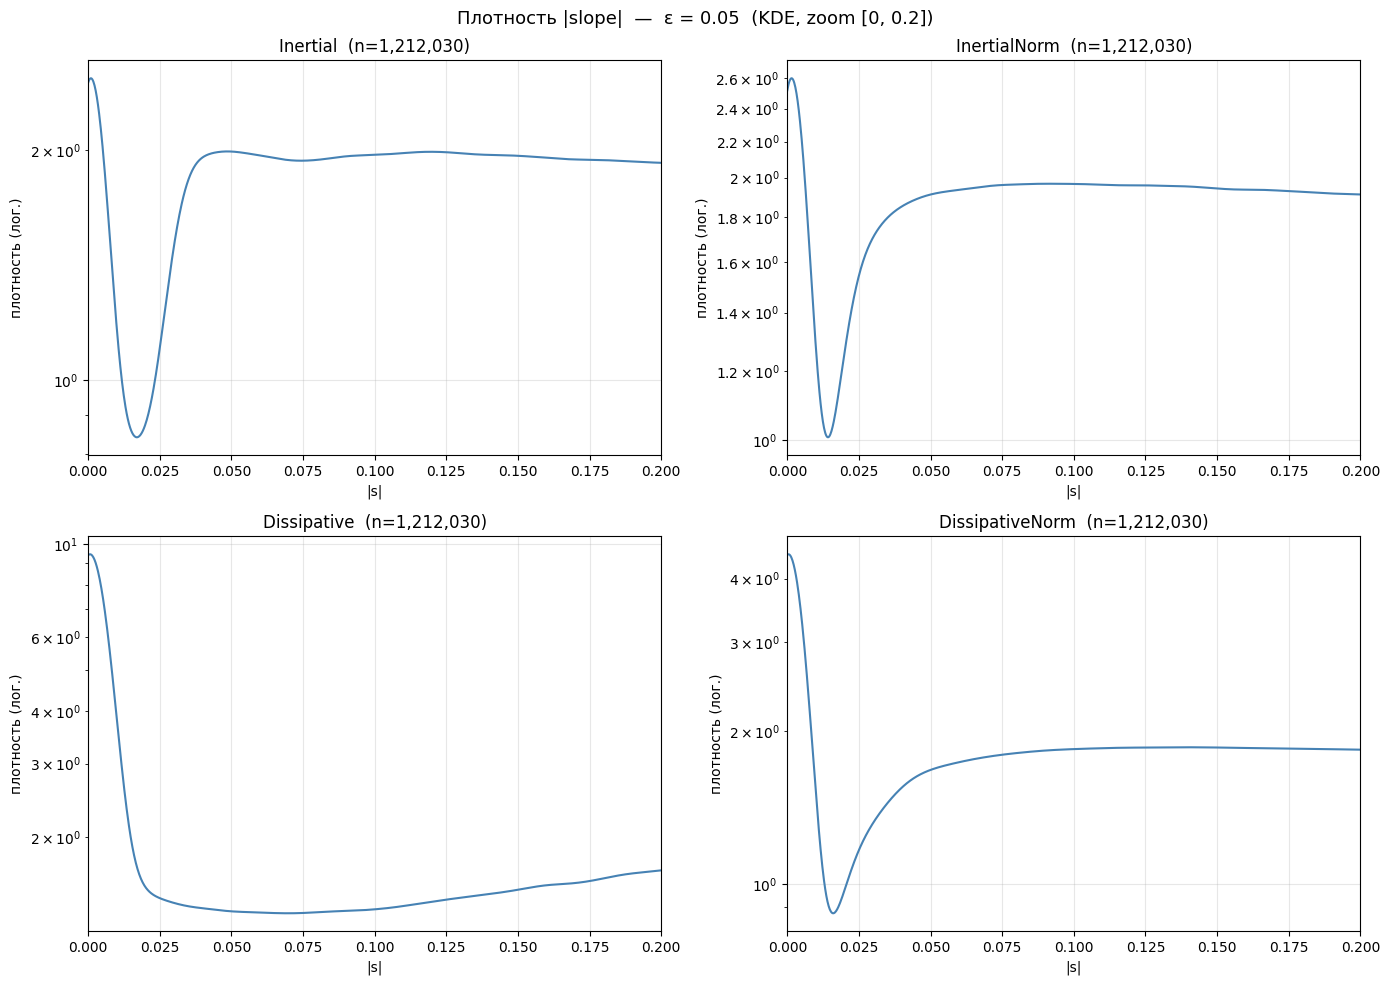

In [234]:
from scipy.stats import gaussian_kde

sub = df[df['eps'] == eps_val()].copy()

slopes = pd.concat([
    sub[['coupling_type', 's01']].rename(columns={'s01': 's'}),
    sub[['coupling_type', 's02']].rename(columns={'s02': 's'}),
    sub[['coupling_type', 's12']].rename(columns={'s12': 's'}),
])
slopes['|s|'] = slopes['s'].abs()

x_max = 0.2
x_grid = np.linspace(0, x_max, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Плотность |slope|  —  ε = {eps_val()}  (KDE, zoom [0, {x_max}])', fontsize=13)

for ct, ax in enumerate(axes.flat):
    data = slopes[slopes['coupling_type'] == ct]['|s|'].values
    kde = gaussian_kde(data, bw_method=0.03)
    ax.semilogy(x_grid, kde(x_grid), color='steelblue', lw=1.5)
    ax.set_xlim(0, x_max)
    ax.set_xlabel('|s|')
    ax.set_ylabel('плотность (лог.)')
    ax.set_title(f'{COUPLING_NAMES[ct]}  (n={len(data):,})')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [235]:
from enum import IntEnum

class CouplingType(IntEnum):
    Inertial        = 0
    InertialNorm    = 1
    Dissipative     = 2
    DissipativeNorm = 3

THETA = {
    CouplingType.Inertial:        0.0225,
    CouplingType.InertialNorm:    0.0225,
    CouplingType.Dissipative:     0.0225,
    CouplingType.DissipativeNorm: 0.0225,
}

## Карты режимов синхронизации

In [236]:
REGIME_LABELS = [
    'нет синхр.',    # 0
    '0↔1',           # 1
    '0↔2',           # 2
    '0↔1, 0↔2',     # 3
    '1↔2',           # 4
    '0↔1, 1↔2',     # 5
    '0↔2, 1↔2',     # 6
    'полная',        # 7
]
REGIME_COLORS = ['#d3d3d3','#4477aa','#66ccee','#228833','#ccbb44','#ee6677','#aa3377','#222222']

def sync_code(row, theta=None):
    t = THETA[CouplingType(int(row['coupling_type']))] if theta is None else theta
    return int(row['s01'] < t) | (int(row['s02'] < t) << 1) | (int(row['s12'] < t) << 2)

def draw_borders(ax, pivot, linewidth=0.6, color='black'):
    # Обводим ГРАНИЦУ мультистабильных областей через contour, а не каждую ячейку
    # прямоугольником: на мелкой сетке (шаг 0.005) рамка Rectangle толще ячейки и
    # заливает её целиком, превращая обводку в сплошные чёрные квадраты.
    d1 = pivot.index.values      # delta1 -> y
    d2 = pivot.columns.values    # delta2 -> x
    Z = np.nan_to_num(pivot.values.astype(float), nan=0.0)
    ax.contour(d2, d1, Z, levels=[0.5], colors=color, linewidths=linewidth)


def codes_for(sub):
    theta = sub['coupling_type'].map(lambda c: THETA[CouplingType(int(c))])
    return ((sub['s01'] < theta).astype(int)
            + (sub['s02'] < theta).astype(int) * 2
            + (sub['s12'] < theta).astype(int) * 4)

from functools import lru_cache

@lru_cache(maxsize=8)
def sub_with_code(eps):
    """Срез df по eps с колонкой code; кэш — чтобы смена ε и перезапуск ячеек были дешёвыми."""
    sub = df[df['eps'] == eps].copy()
    sub['code'] = codes_for(sub)
    return sub

def plot_regime_maps(eps):
    sub = sub_with_code(eps)
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        dominant_code=('code', lambda x: x.value_counts().idxmax()),
        multi_regime=('code', lambda x: x.nunique() > 1),
    ).reset_index()
    
    cmap = mcolors.ListedColormap(REGIME_COLORS)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Режимы синхронизации  ε = {eps}', fontsize=13)
    
    for ct in range(4):
        ax = axes[ct // 2, ct % 2]
        data = agg[agg['coupling_type'] == ct]
        
        dom     = data.pivot(index='delta1', columns='delta2', values='dominant_code')
        mul_reg = data.pivot(index='delta1', columns='delta2', values='multi_regime')
        
        ax.pcolormesh(dom.columns, dom.index, dom.values, cmap=cmap, norm=norm, shading='auto')
        draw_borders(ax, mul_reg, linewidth=0.6, color='black')
        
        ax.set_title(f'{COUPLING_NAMES[ct]}  θ = {THETA[CouplingType(ct)]}')
        ax.set_xlabel('δ₂'); ax.set_ylabel('δ₁')
        
        present = sorted(data['dominant_code'].unique())
        handles = [Patch(facecolor=REGIME_COLORS[c], label=REGIME_LABELS[c]) for c in present]
        handles.append(Patch(facecolor='white', edgecolor='black', label='мультистабильно'))
        ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=7)
    
    plt.tight_layout()
    plt.show()

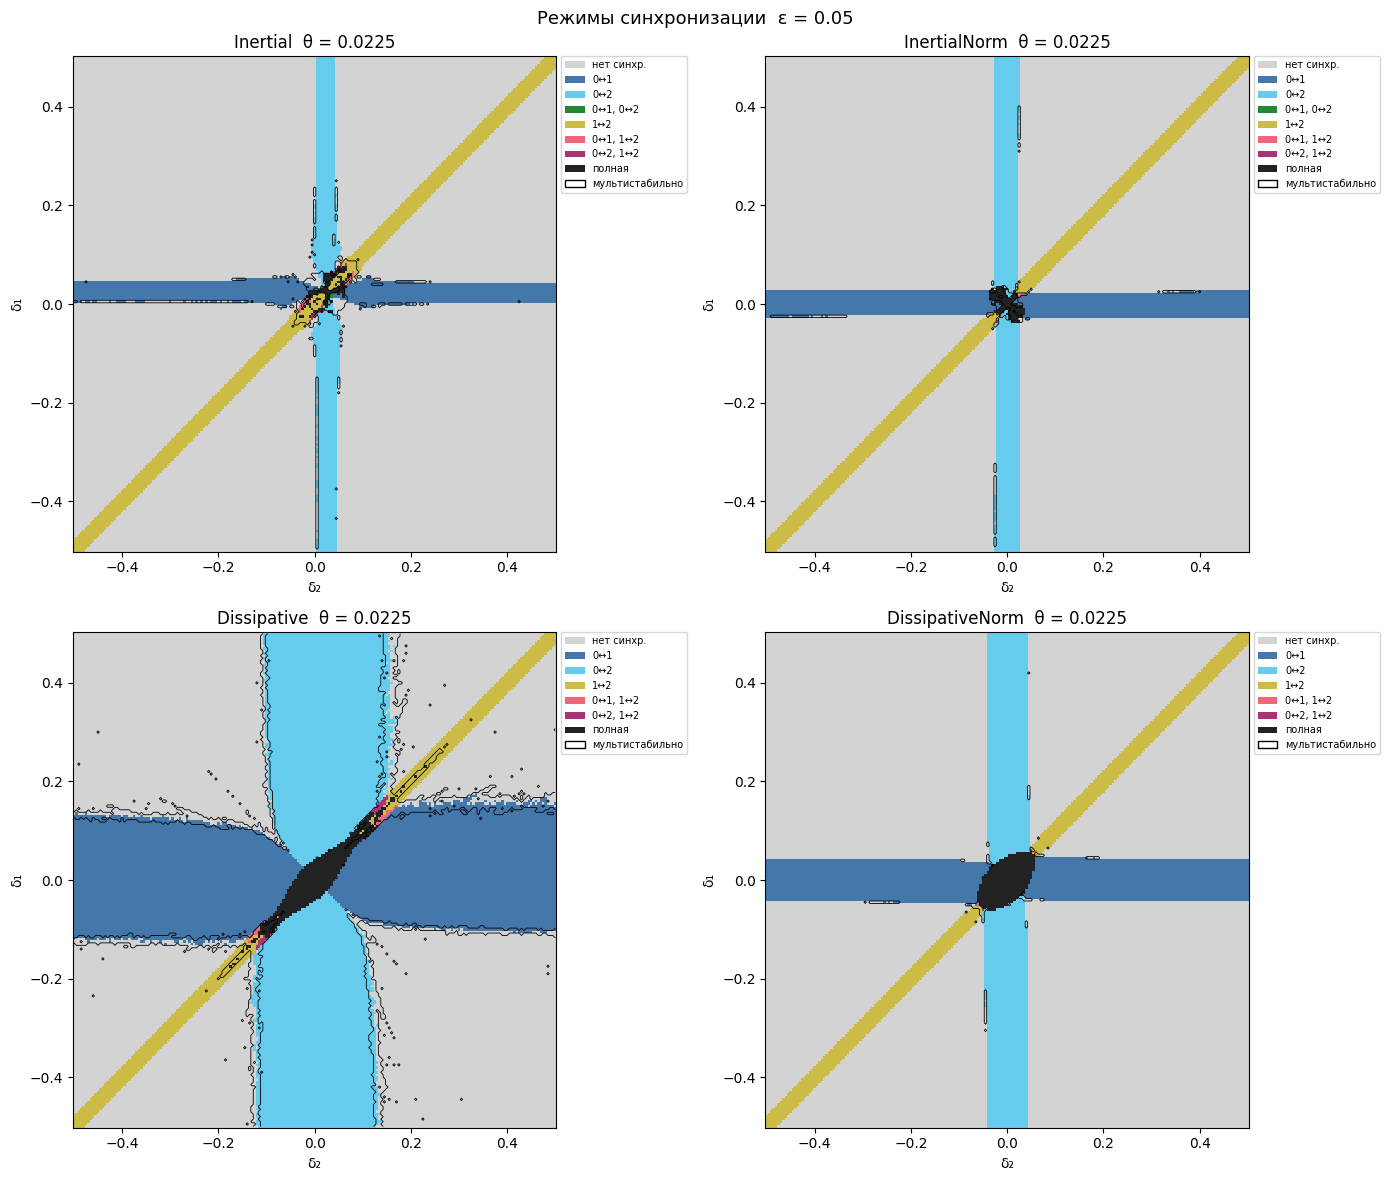

In [237]:
plot_regime_maps(eps_val())

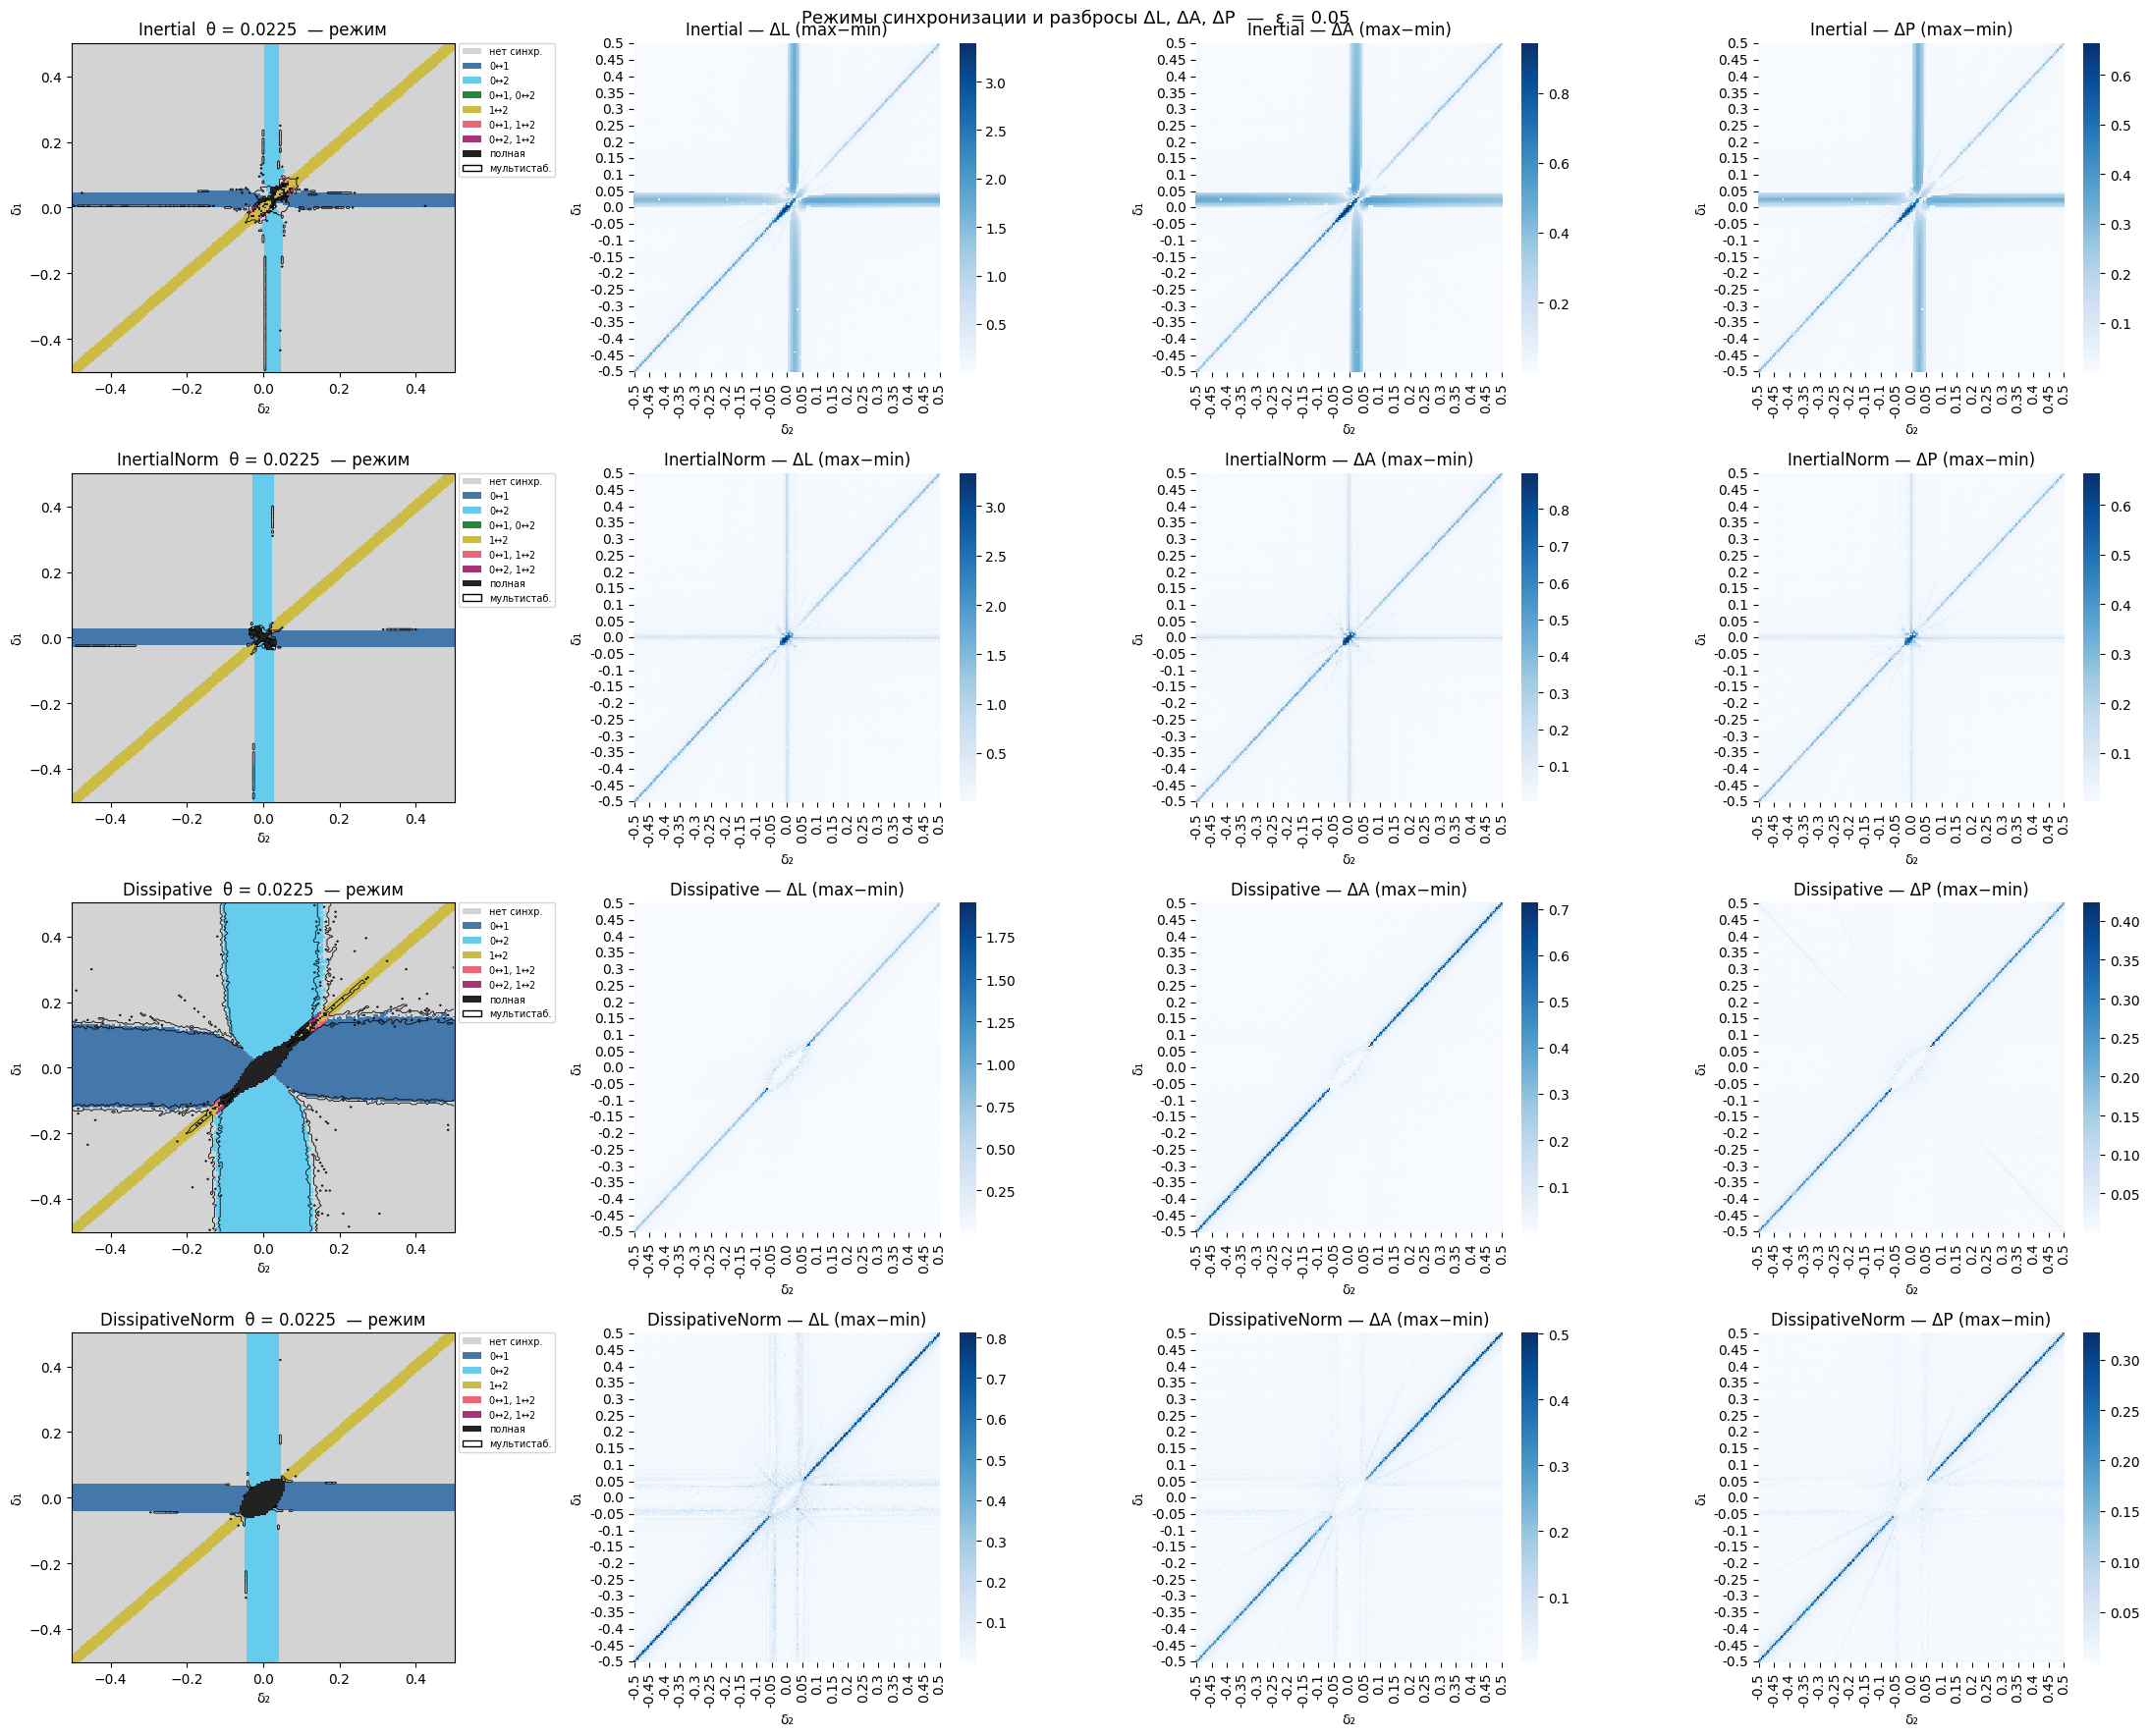

In [238]:
def plot_regime_vs_spreads(eps):
    sub = sub_with_code(eps)

    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        dominant_code=('code', lambda x: x.value_counts().idxmax()),
        l_spread=('L', lambda x: x.max() - x.min()),
        a_spread=('A', lambda x: x.max() - x.min()),
        p_spread=('P', lambda x: x.max() - x.min()),
        multi_regime=('code', lambda x: x.nunique() > 1),
    ).reset_index()

    cmap_reg = mcolors.ListedColormap(REGIME_COLORS)
    norm_reg = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)
    spreads = [('l_spread', 'ΔL'), ('a_spread', 'ΔA'), ('p_spread', 'ΔP')]

    fig, axes = plt.subplots(4, 4, figsize=(22, 18))
    fig.suptitle(f'Режимы синхронизации и разбросы ΔL, ΔA, ΔP  —  ε = {eps}', fontsize=13)

    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        dom     = data.pivot(index='delta1', columns='delta2', values='dominant_code')
        mul_reg = data.pivot(index='delta1', columns='delta2', values='multi_regime')

        ax_reg = axes[ct, 0]
        ax_reg.pcolormesh(dom.columns, dom.index, dom.values,
                          cmap=cmap_reg, norm=norm_reg, shading='auto')
        draw_borders(ax_reg, mul_reg)
        ax_reg.set_title(f'{COUPLING_NAMES[ct]}  θ = {THETA[CouplingType(ct)]}  — режим')
        ax_reg.set_xlabel('δ₂'); ax_reg.set_ylabel('δ₁')
        present = sorted(data['dominant_code'].unique())
        handles = [Patch(facecolor=REGIME_COLORS[c], label=REGIME_LABELS[c]) for c in present]
        handles.append(Patch(facecolor='white', edgecolor='black', label='мультистаб.'))
        ax_reg.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=7)

        for col_idx, (spread_col, spread_label) in enumerate(spreads, start=1):
            spread = data.pivot(index='delta1', columns='delta2', values=spread_col)
            ax = axes[ct, col_idx]
            sns.heatmap(spread.iloc[::-1], cmap='Blues', ax=ax,
                        xticklabels=10, yticklabels=10)
            ax.set_title(f'{COUPLING_NAMES[ct]} — {spread_label} (max−min)')
            ax.set_xlabel('δ₂'); ax.set_ylabel('δ₁')

    plt.tight_layout()
    plt.show()

plot_regime_vs_spreads(eps_val())

## Целевые функции

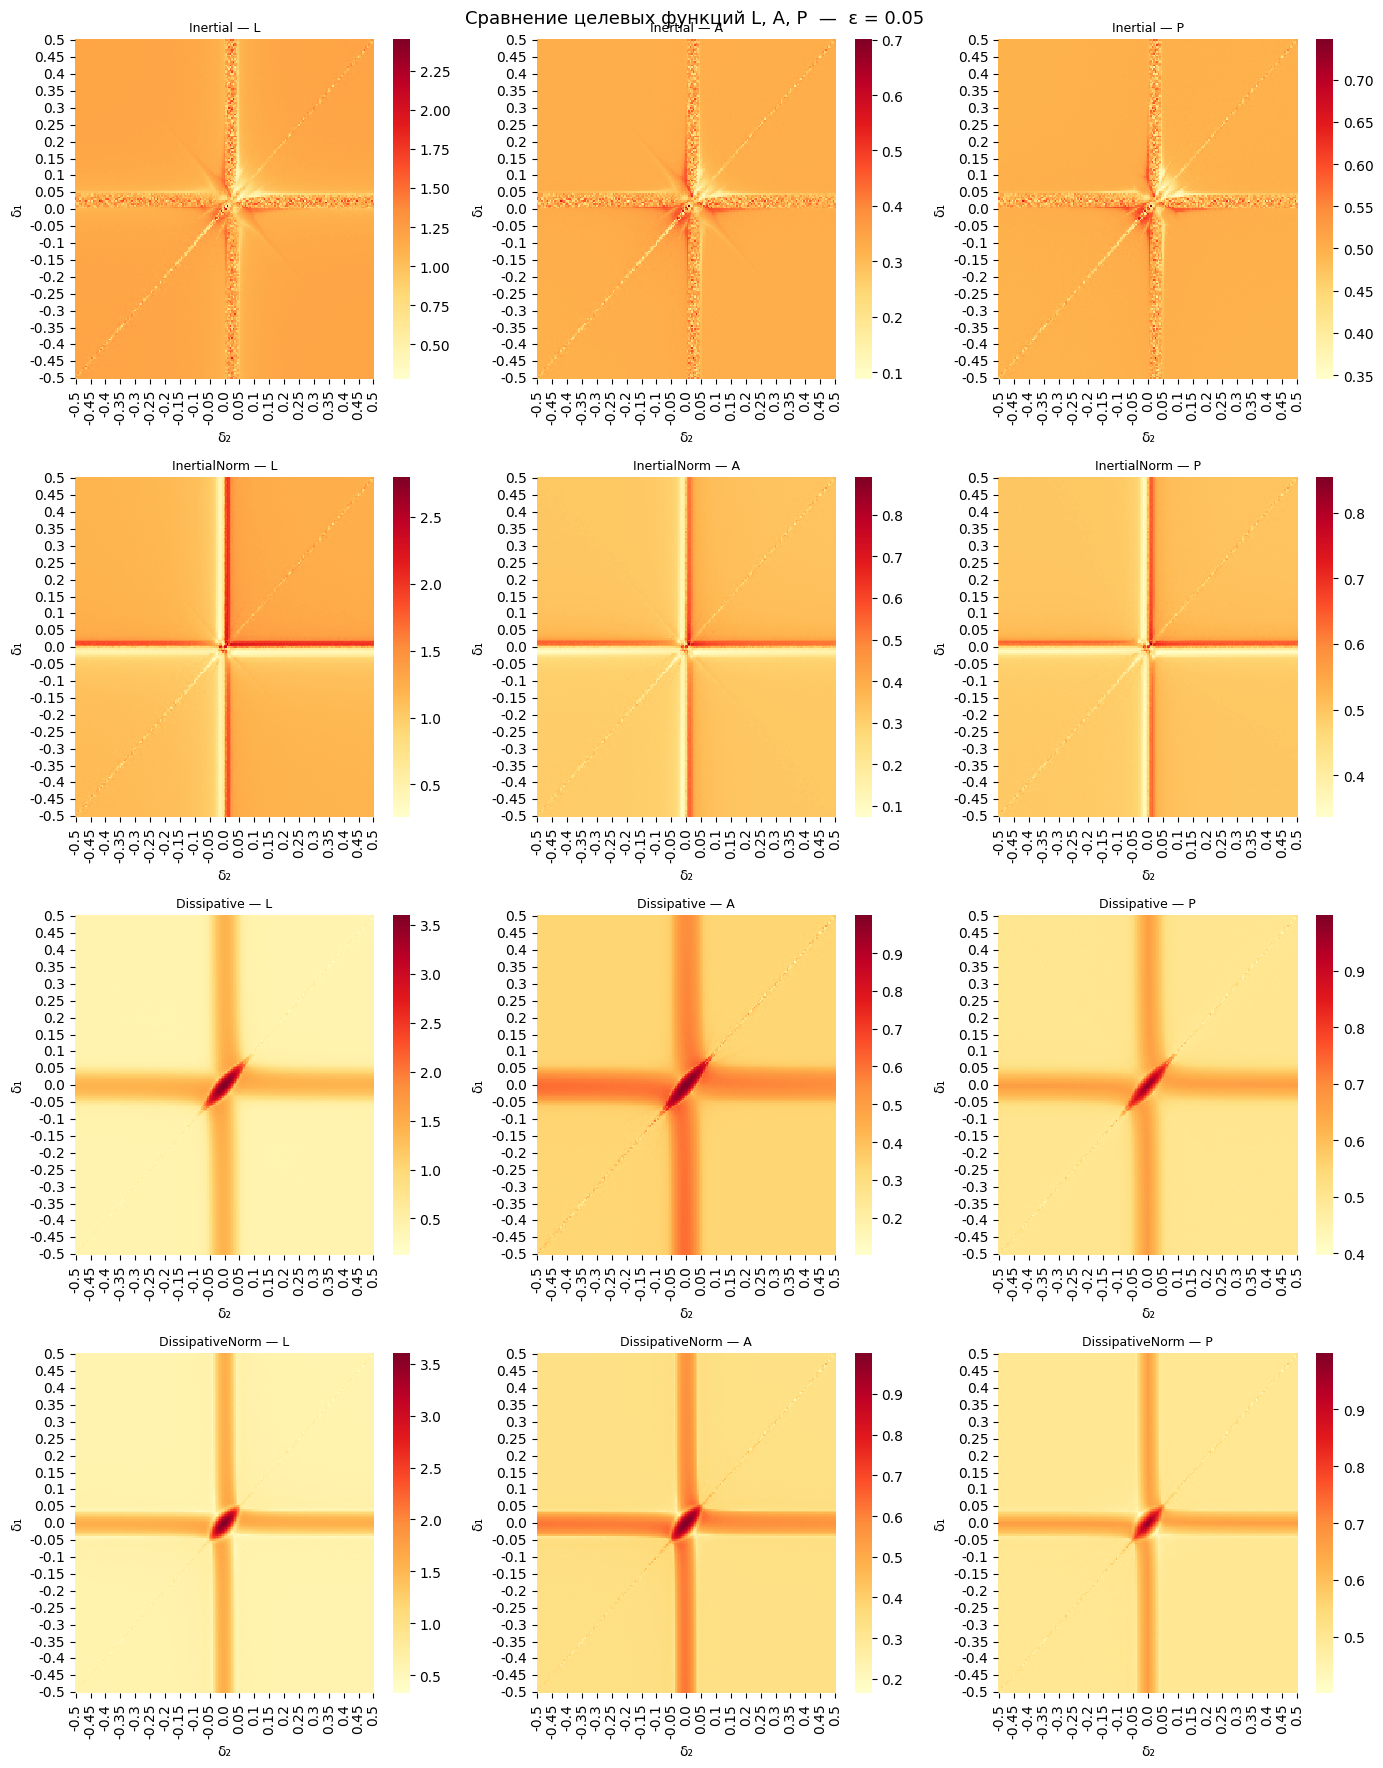

In [239]:
def plot_goal_maps(eps):
    sub = df[df['eps'] == eps]
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        L=('L', 'mean'),
        A=('A', 'mean'),
        P=('P', 'mean'),
    ).reset_index()

    fig, axes = plt.subplots(4, 3, figsize=(14, 18))
    fig.suptitle(f'Сравнение целевых функций L, A, P  —  ε = {eps}', fontsize=13)

    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        for col, col_name in enumerate(['L', 'A', 'P']):
            pivot = data.pivot(index='delta1', columns='delta2', values=col_name).iloc[::-1]
            sns.heatmap(pivot, cmap='YlOrRd', ax=axes[ct, col],
                        xticklabels=10, yticklabels=10)
            axes[ct, col].set_title(f'{COUPLING_NAMES[ct]} — {col_name}', fontsize=9)
            axes[ct, col].set_xlabel('δ₂'); axes[ct, col].set_ylabel('δ₁')

    plt.tight_layout()
    plt.show()

plot_goal_maps(eps_val())

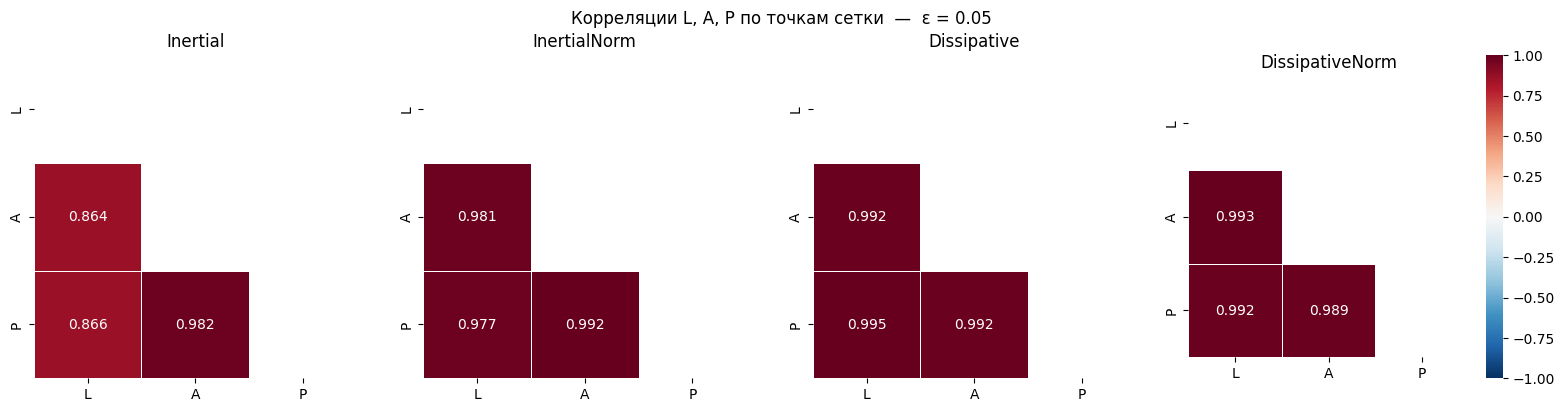

In [240]:
import seaborn as sns

def goal_correlations(eps):
    sub = df[df['eps'] == eps]
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type'])[['L', 'A', 'P']].mean().reset_index()

    mask = np.triu(np.ones((3, 3), dtype=bool))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Корреляции L, A, P по точкам сетки  —  ε = {eps}', fontsize=12)

    for ct in range(4):
        corr = agg[agg['coupling_type'] == ct][['L', 'A', 'P']].corr()
        sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
                    vmin=-1, vmax=1, cmap='RdBu_r',
                    ax=axes[ct], square=True, linewidths=0.5,
                    cbar=(ct == 3))
        axes[ct].set_title(COUPLING_NAMES[ct])

    plt.tight_layout()
    plt.show()

goal_correlations(eps_val())

In [241]:
from IPython.display import display, Markdown

sub15 = df[df['eps'] == eps_val()]
agg15 = sub15.groupby(['delta1', 'delta2', 'coupling_type'])[['L', 'A', 'P']].mean().reset_index()

rows = []
for ct in range(4):
    c = agg15[agg15['coupling_type'] == ct][['L', 'A', 'P']].corr()
    rows.append((COUPLING_NAMES[ct], c.loc['L', 'A'], c.loc['L', 'P'], c.loc['A', 'P']))

corr_lines = '  \n'.join(
    f'**{name}**: ρ(L,A) = {la:.3f}, ρ(L,P) = {lp:.3f}, ρ(A,P) = {ap:.3f}'
    for name, la, lp, ap in rows
)
weakest_ap = min(rows, key=lambda r: r[3])
weakest_la = min(rows, key=lambda r: r[1])

## Синфазность внутри областей захвата

Карты режимов отвечают на вопрос «где синхронно», но не «где синфазно». Здесь поверх
приглушённой карты режимов (фон) выводится $P$ только в зоне полной синхронизации (код 7):
$P = 1 - \frac{2}{\pi n (n-1)} \sum_{i<j} |\Delta\varphi_{ij}|$ — внутри захвата все
$\Delta\varphi_{ij}$ постоянны, и $P$ напрямую переводится в средний сдвиг фаз:
$P \approx 1$ — синфазно, меньше — захват со сдвигом. Так видно, что синфазная зона —
подмножество зоны захвата.

Сама по себе карта $P$ (без маски) это не показывает: вне захвата у $P$ базлайн $\approx 0.5$,
а не 0 — фаза $\mathrm{atan2}(\dot x, x)$ бежит по циклу ВдП неравномерно, и $|\Delta\varphi|$
даже независимых осцилляторов в среднем меньше $\pi/2$.

Осторожно с «крапчатыми» зонами: там $\langle P \rangle$ усреднён по НУ, которые
сходятся к разным фазовым конфигурациям, и цвет не описывает ни одну из них.

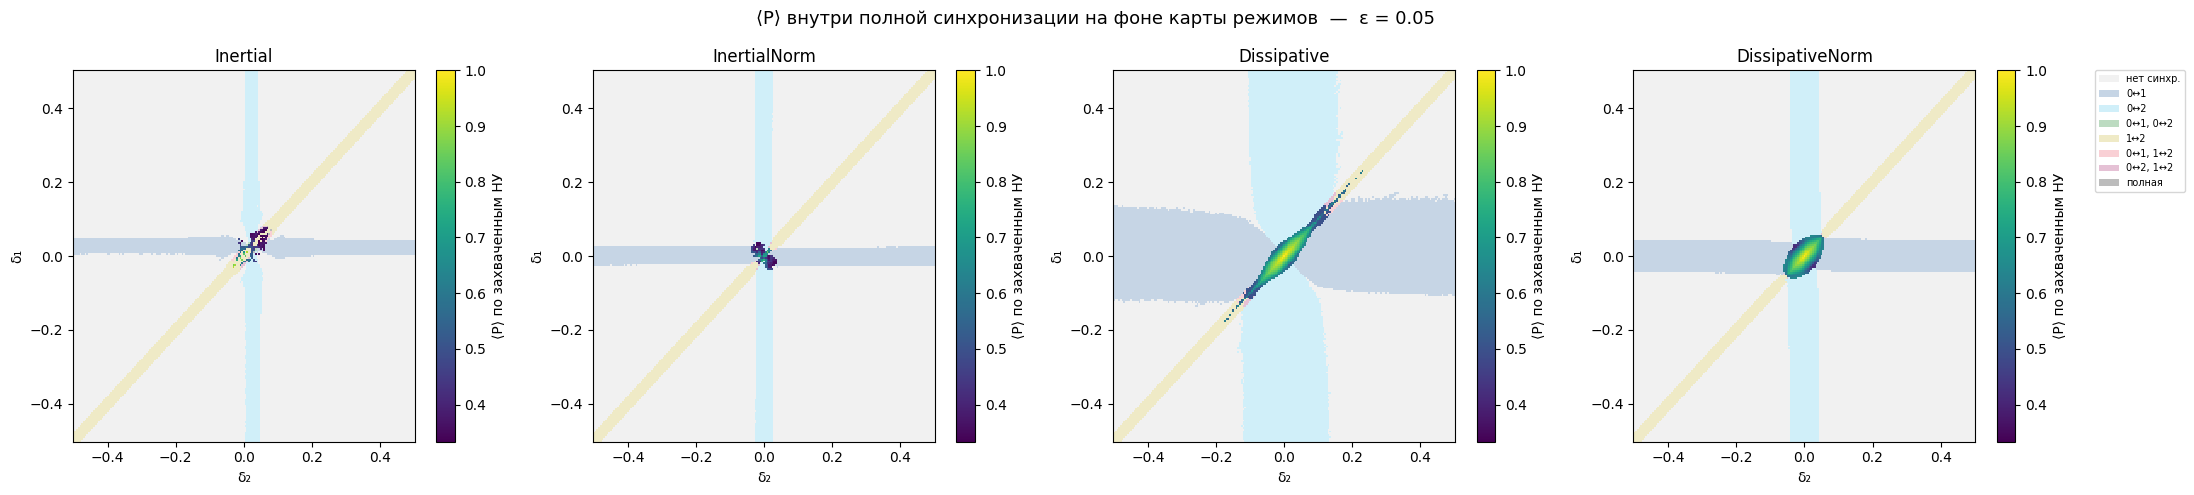

In [242]:
sub = sub_with_code(eps_val())
keys = ['delta1', 'delta2', 'coupling_type']
full = sub[sub['code'] == 7]

# доминирующий код — быстро, через счётчики вместо value_counts().idxmax()
counts = sub.groupby(keys + ['code']).size().reset_index(name='n')
agg = counts.sort_values('n').drop_duplicates(keys, keep='last') \
            .rename(columns={'code': 'dominant_code'})[keys + ['dominant_code']]
agg = agg.merge(
    sub.assign(is_full=sub['code'] == 7).groupby(keys)['is_full'].mean()
       .rename('full_frac').reset_index(), on=keys)
p_stats = full.groupby(keys)['P'].agg(P_sync='mean').reset_index()
agg = agg.merge(p_stats, on=keys, how='left')
agg.loc[agg['full_frac'] < 0.5, 'P_sync'] = np.nan

cmap_reg = mcolors.ListedColormap(REGIME_COLORS)
norm_reg = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)
cm_p = plt.get_cmap('viridis').copy()
cm_p.set_bad(alpha=0)  # вне полного захвата просвечивает фон с режимами

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(f'⟨P⟩ внутри полной синхронизации на фоне карты режимов  —  ε = {eps_val()}', fontsize=13)

for ct, ax in enumerate(axes):
    data = agg[agg['coupling_type'] == ct]
    dom = data.pivot(index='delta1', columns='delta2', values='dominant_code')
    ax.pcolormesh(dom.columns, dom.index, dom.values,
                  cmap=cmap_reg, norm=norm_reg, shading='auto', alpha=0.3)
    p_piv = data.pivot(index='delta1', columns='delta2', values='P_sync')
    m = ax.pcolormesh(p_piv.columns, p_piv.index, np.ma.masked_invalid(p_piv.values),
                      cmap=cm_p, vmin=1/3, vmax=1.0, shading='auto')
    fig.colorbar(m, ax=ax, label='⟨P⟩ по захваченным НУ')
    ax.set_title(COUPLING_NAMES[ct])
    ax.set_xlabel('δ₂'); ax.set_ylabel('δ₁')

handles = [Patch(facecolor=c, alpha=0.3, label=l) for c, l in zip(REGIME_COLORS, REGIME_LABELS)]
axes[-1].legend(handles=handles, loc='upper left', bbox_to_anchor=(1.35, 1), borderaxespad=0, fontsize=7)

plt.tight_layout()
plt.show()

## Мультистабильность

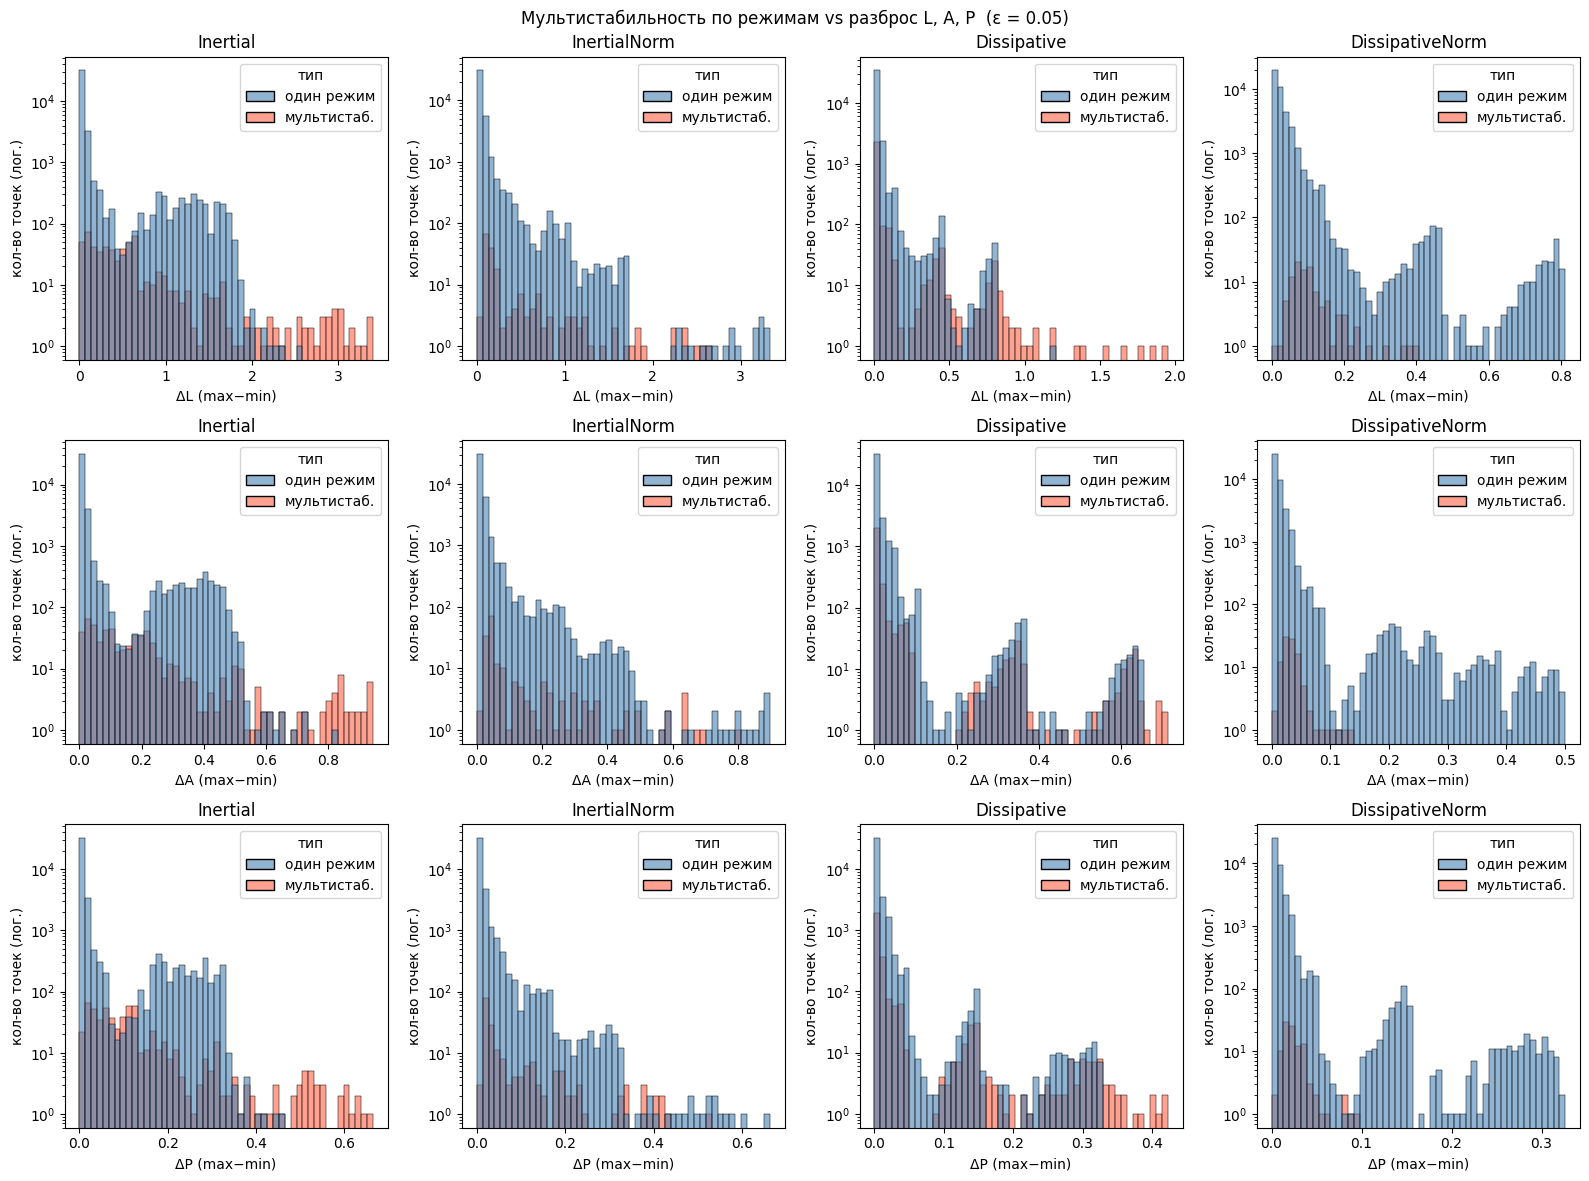

In [243]:
sub = sub_with_code(eps_val())

agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
    multi_regime=('code', lambda x: x.nunique() > 1),
    l_spread=('L', lambda x: x.max() - x.min()),
    a_spread=('A', lambda x: x.max() - x.min()),
    p_spread=('P', lambda x: x.max() - x.min()),
).reset_index()
agg['тип'] = agg['multi_regime'].map({True: 'мультистаб.', False: 'один режим'})

metrics = [('l_spread', 'ΔL (max−min)'), ('a_spread', 'ΔA (max−min)'), ('p_spread', 'ΔP (max−min)')]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f'Мультистабильность по режимам vs разброс L, A, P  (ε = {eps_val()})')

for row_idx, (col_name, xlabel) in enumerate(metrics):
    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        sns.histplot(data=data, x=col_name, hue='тип', bins=50, alpha=0.6,
                     ax=axes[row_idx, ct], element='bars',
                     palette={'один режим': 'steelblue', 'мультистаб.': 'tomato'})
        axes[row_idx, ct].set_yscale('log')
        axes[row_idx, ct].set_title(COUPLING_NAMES[ct])
        axes[row_idx, ct].set_xlabel(xlabel)
        axes[row_idx, ct].set_ylabel('кол-во точек (лог.)')

plt.tight_layout()
plt.show()

## Исследование $\Delta L$, $\Delta A$, $\Delta P$ как критериев мультистабильности

**Постановка вопроса.**
Проверялась гипотеза: можно ли использовать разброс когерентности
$\Delta L$ $\Delta A$ и $\Delta P$ по $n_{\text{ic}}$ начальным условиям
как индикатор мультистабильности — альтернативу критерию по разнообразию sync\_code.

**Построение гистограмм.**
Для $\varepsilon = 0.1$, по всем типам связи и всем точкам сетки $(\delta_1, \delta_2)$
вычислялись $\Delta L$, $\Delta A$, $\Delta P$ и флаг мультистабильности (истина, если по 10 НУ встречается $> 1$ значения sync\_code).
Построены гистограммы раздельно для моно- и мультирежимных точек (лог. шкала).
Распределения не разделились — гипотеза отвергнута для всех трёх метрик.

Для $\Delta L$ подтверждение выбраны два контрпримера (ниже).

### Поиск контрпримеров

In [244]:
## Верификация методологии

sub = sub_with_code(eps_val())

agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
    multi_regime=('code', lambda x: x.nunique() > 1),
    l_spread=('L', lambda x: x.max() - x.min()),
    a_spread=('A', lambda x: x.max() - x.min()),
    p_spread=('P', lambda x: x.max() - x.min()),
    codes=('code', list),
    L_vals=('L', list),
    A_vals=('A', list),
    P_vals=('P', list),
).reset_index()

ct = 0  # Inertial
data = agg[agg['coupling_type'] == ct]

# 1. Пример точки с мультистабильностью и малым l_spread
multi_small = data[data['multi_regime'] & (data['l_spread'] < 0.1)].head(3)
print("=== Мультистабильные точки с малым ΔL (<0.1) ===")
for _, row in multi_small.iterrows():
    print(f"  δ1={row.delta1:.2f} δ2={row.delta2:.2f}  ΔL={row.l_spread:.4f}  ΔA={row.a_spread:.4f}  ΔP={row.p_spread:.4f}")
    print(f"  коды по 10 НУ: {row.codes}")
    print(f"  L: {[round(x,3) for x in row.L_vals]}")
    print(f"  A: {[round(x,3) for x in row.A_vals]}")
    print(f"  P: {[round(x,3) for x in row.P_vals]}")

print()

# 2. Пример точки с одним режимом и большим l_spread
mono_large = data[~data['multi_regime'] & (data['l_spread'] > 0.5)].head(3)
print("=== Одно-режимные точки с большим ΔL (>0.5) ===")
for _, row in mono_large.iterrows():
    print(f"  δ1={row.delta1:.2f} δ2={row.delta2:.2f}  ΔL={row.l_spread:.4f}  ΔA={row.a_spread:.4f}  ΔP={row.p_spread:.4f}")
    print(f"  коды по 10 НУ: {row.codes}")
    print(f"  L: {[round(x,3) for x in row.L_vals]}")
    print(f"  A: {[round(x,3) for x in row.A_vals]}")
    print(f"  P: {[round(x,3) for x in row.P_vals]}")

print()

=== Мультистабильные точки с малым ΔL (<0.1) ===
  δ1=-0.18 δ2=0.05  ΔL=0.0351  ΔA=0.0110  ΔP=0.0079
  коды по 10 НУ: [0, 0, 0, 0, 0, 0, 2, 0, 2, 0]
  L: [0.838, 0.816, 0.832, 0.818, 0.813, 0.827, 0.839, 0.844, 0.808, 0.81]
  A: [0.262, 0.254, 0.258, 0.256, 0.256, 0.258, 0.26, 0.264, 0.254, 0.253]
  P: [0.463, 0.458, 0.457, 0.46, 0.46, 0.46, 0.458, 0.464, 0.458, 0.456]
  δ1=-0.17 δ2=0.05  ΔL=0.0300  ΔA=0.0096  ΔP=0.0088
  коды по 10 НУ: [0, 0, 2, 0, 0, 2, 0, 0, 0, 0]
  L: [0.831, 0.816, 0.812, 0.806, 0.813, 0.818, 0.819, 0.825, 0.836, 0.827]
  A: [0.261, 0.254, 0.251, 0.252, 0.256, 0.258, 0.253, 0.26, 0.261, 0.258]
  P: [0.46, 0.452, 0.453, 0.454, 0.457, 0.458, 0.456, 0.459, 0.461, 0.455]
  δ1=-0.17 δ2=0.05  ΔL=0.0312  ΔA=0.0107  ΔP=0.0106
  коды по 10 НУ: [0, 2, 0, 0, 0, 0, 0, 0, 0, 2]
  L: [0.824, 0.808, 0.831, 0.8, 0.824, 0.82, 0.811, 0.802, 0.825, 0.812]
  A: [0.255, 0.255, 0.259, 0.248, 0.256, 0.257, 0.25, 0.249, 0.258, 0.252]
  P: [0.457, 0.448, 0.456, 0.452, 0.451, 0.456, 0.455,

### Проверка точки с маленьким $\Delta L$, но мультистабильностью

In [245]:
if len(multi_small) == 0:
    print("Контрпримеров (мультистаб. с малым ΔL) не найдено в текущих данных")
else:
    r0 = multi_small.iloc[0]
    d1, d2 = r0.delta1, r0.delta2
    point = df[
        (df['eps'] == eps_val()) &
        (df['coupling_type'] == 0) &
        (np.isclose(df['delta1'], d1, atol=0.01)) &
        (np.isclose(df['delta2'], d2, atol=0.01))
    ].copy()
    point['code'] = point.apply(lambda r: sync_code(r), axis=1)
    print(f"δ1={d1:.2f}, δ2={d2:.2f}, Inertial — все прогоны (ΔL={r0.l_spread:.4f}):")
    print(f"{'код':>5}  {'L':>6}  {'x0':>7}  {'y0':>7}  {'x1':>7}  {'y1':>7}  {'x2':>7}  {'y2':>7}")
    for _, r in point.iterrows():
        print(f"{int(r.code):>5}  {r.L:>6.3f}  {r.x0:>7.3f}  {r.y0:>7.3f}  {r.x1:>7.3f}  {r.y1:>7.3f}  {r.x2:>7.3f}  {r.y2:>7.3f}")

δ1=-0.18, δ2=0.05, Inertial — все прогоны (ΔL=0.0351):
  код       L       x0       y0       x1       y1       x2       y2
    2   0.649    0.000   -1.466   -0.917    0.340    2.632    2.798
    2   1.526   -0.297    2.317    2.905   -1.637   -0.670    1.582
    2   1.515   -0.063   -1.730    2.180   -2.420   -1.116   -1.425
    2   0.648   -1.797   -1.020   -0.502    0.618   -1.532    0.542
    2   0.647   -1.481    2.452    2.493   -0.233    1.095   -0.275
    2   1.548    0.362    0.632   -1.147   -2.955    1.368    0.481
    2   1.553   -2.581   -1.944   -0.161   -0.525   -2.431   -1.507
    2   1.556    1.117   -0.131   -2.239   -0.757    1.871    0.374
    2   0.646    0.552   -1.347    1.397    1.497   -1.339   -0.393
    2   1.549   -0.812    1.391   -2.726   -2.717   -0.165    2.572
    2   0.743    1.755   -1.115    1.235   -2.756    2.521    2.692
    2   0.754    0.147    1.511   -2.498    1.050   -1.638   -2.707
    2   0.743    2.902    1.504    2.146    2.954    1.378   

### Проверка точки с высоким $\Delta L$, но однорежимностью

In [246]:
if len(mono_large) == 0:
    print("Контрпримеров (один режим с большим ΔL) не найдено в текущих данных")
else:
    r0 = mono_large.iloc[0]
    d1, d2 = r0.delta1, r0.delta2
    point2 = df[
        (df['eps'] == eps_val()) &
        (df['coupling_type'] == 0) &
        (np.isclose(df['delta1'], d1, atol=0.01)) &
        (np.isclose(df['delta2'], d2, atol=0.01))
    ].copy()
    point2['code'] = point2.apply(lambda r: sync_code(r), axis=1)
    print(f"δ1={d1:.2f}, δ2={d2:.2f}, Inertial — все прогоны (ΔL={r0.l_spread:.4f}):")
    print(f"{'код':>5}  {'L':>6}  {'x0':>7}  {'y0':>7}  {'x1':>7}  {'y1':>7}  {'x2':>7}  {'y2':>7}")
    for _, r in point2.iterrows():
        print(f"{int(r.code):>5}  {r.L:>6.3f}  {r.x0:>7.3f}  {r.y0:>7.3f}  {r.x1:>7.3f}  {r.y1:>7.3f}  {r.x2:>7.3f}  {r.y2:>7.3f}")

δ1=-0.50, δ2=-0.50, Inertial — все прогоны (ΔL=1.7355):
  код       L       x0       y0       x1       y1       x2       y2
    4   0.340    2.857    0.512   -2.620    2.443   -1.260    0.766
    4   2.050   -2.062    2.941    1.335   -1.567   -1.579   -1.246
    4   0.315    0.347    1.197    0.818    1.753    1.185   -1.646
    4   2.018   -2.886    0.939    0.771    1.631   -2.901    2.440
    4   1.341   -0.471   -2.478   -1.160   -1.273    0.754   -2.569
    4   0.332    2.683   -2.432    0.563    1.767    0.442   -2.165
    4   0.390   -1.413   -0.846   -2.813    0.674   -0.198   -1.386
    4   1.283    0.602   -2.497   -2.780   -2.964    1.557   -2.544
    4   0.317   -1.926    0.580   -0.856    2.285   -2.194    0.474
    4   1.373   -1.781    1.186    0.349    0.747   -1.435    1.849
    4   0.622    2.438   -0.859   -2.122    1.303   -2.906   -0.940
    4   1.047   -1.758   -2.847    0.453    0.157    1.068   -2.534
    4   1.452    1.931    1.615    1.668   -2.749    1.161  

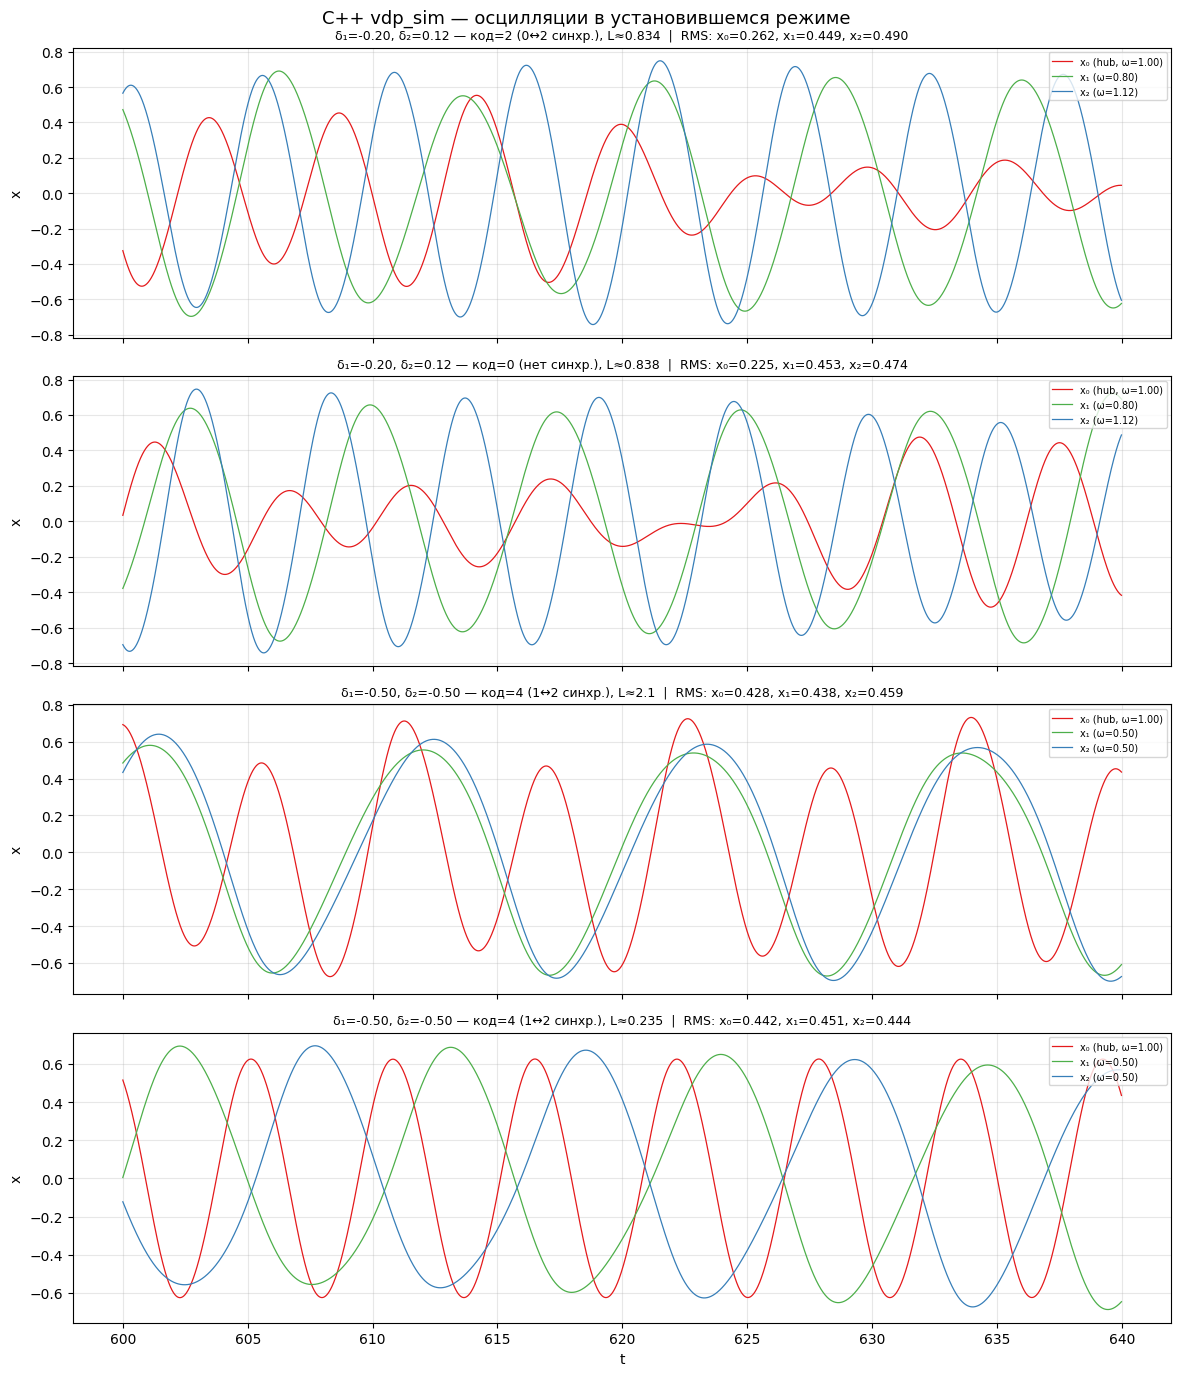

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t_trans = 600.0
plot_window = 40.0

runs = [
    {
        'title': 'δ₁=-0.20, δ₂=0.12 — код=2 (0↔2 синхр.), L≈0.834',
        'path': '../simulation/demo/small_l_code2.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.80)', 'x₂ (ω=1.12)'],
    },
    {
        'title': 'δ₁=-0.20, δ₂=0.12 — код=0 (нет синхр.), L≈0.838',
        'path': '../simulation/demo/small_l_code0.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.80)', 'x₂ (ω=1.12)'],
    },
    {
        'title': 'δ₁=-0.50, δ₂=-0.50 — код=4 (1↔2 синхр.), L≈2.1',
        'path': '../simulation/demo/large_dl_high_l.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.50)', 'x₂ (ω=0.50)'],
    },
    {
        'title': 'δ₁=-0.50, δ₂=-0.50 — код=4 (1↔2 синхр.), L≈0.235',
        'path': '../simulation/demo/large_dl_low_l.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.50)', 'x₂ (ω=0.50)'],
    },
]

colors = ['#e41a1c', '#4daf4a', '#377eb8']

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
fig.suptitle('C++ vdp_sim — осцилляции в установившемся режиме', fontsize=13)

for ax, run in zip(axes, runs):
    df_run = pd.read_csv(run['path'], comment='#')
    steady = df_run[(df_run['t'] >= t_trans) & (df_run['t'] < t_trans + plot_window)]

    for col, c, lbl in zip(['x0', 'x1', 'x2'], colors, run['labels']):
        ax.plot(steady['t'], steady[col], color=c, lw=0.9, label=lbl)

    rms = [np.sqrt((steady[f'x{i}']**2).mean()) for i in range(3)]
    ax.set_title(f"{run['title']}  |  RMS: x₀={rms[0]:.3f}, x₁={rms[1]:.3f}, x₂={rms[2]:.3f}",
                 fontsize=9)
    ax.set_ylabel('x')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()